In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

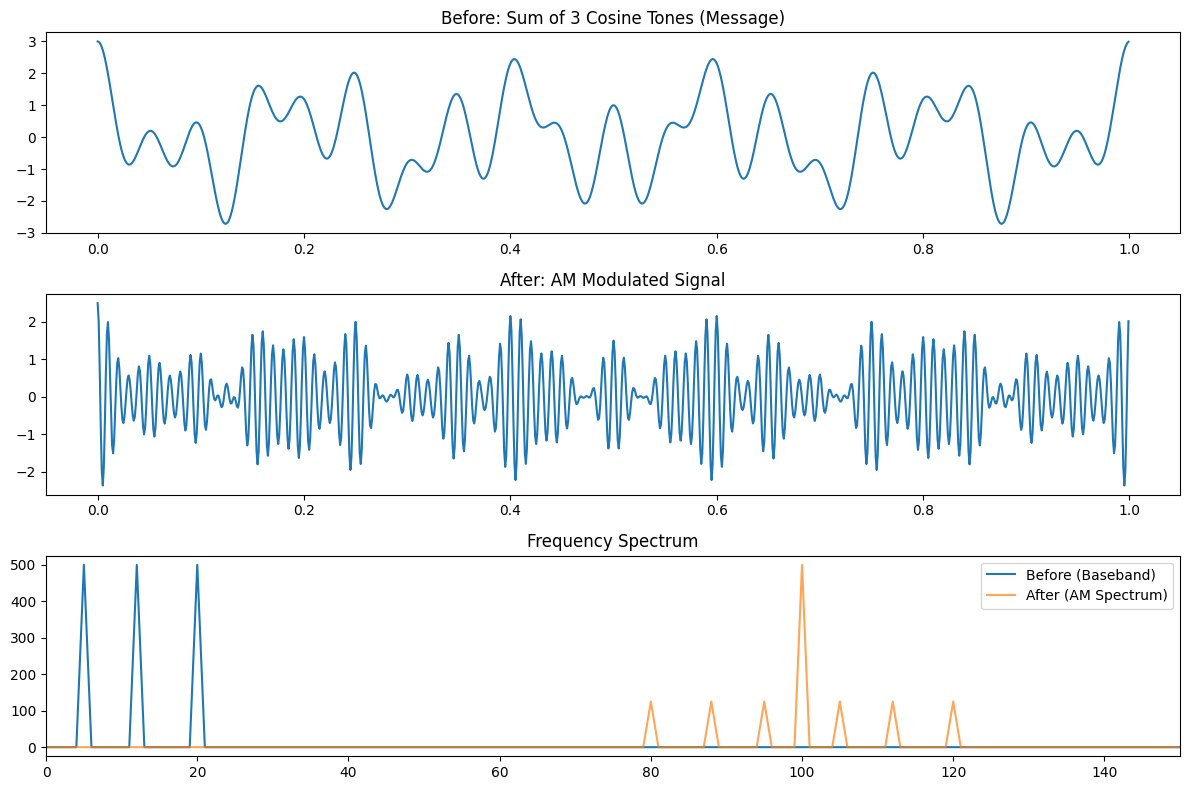

In [6]:
# Parameters
fs = 1000  # Sampling frequency
t = np.arange(0, 1, 1/fs)
fc = 122e6 # Carrier frequency (122MHz) - Using 122 for visualization purposes in plot
           # Note: For actual 122MHz, fs would need to be > 244MHz. 
           # I'll use a scaled-down fc=100Hz for the plot to keep it visible.

# 1. Generate 3 cos tones sum (Message signal)
m_t = np.cos(2 * np.pi * 5 * t) + np.cos(2 * np.pi * 12 * t) + np.cos(2 * np.pi * 20 * t)

# 2. AM Modulation (Carrier fc = 100Hz for visualization)
fc_vis = 100 
carrier = np.cos(2 * np.pi * fc_vis * t)
am_signal = (1 + 0.5 * m_t) * carrier # Mod index 0.5

# 3. Spectrum (FFT)
freq = np.fft.rfftfreq(len(t), 1/fs)
spectrum_before = np.abs(np.fft.rfft(m_t))
spectrum_after = np.abs(np.fft.rfft(am_signal))

# Plotting
plt.figure(figsize=(12, 8))

# Time Domain
plt.subplot(3, 1, 1)
plt.plot(t, m_t)
plt.title("Before: Sum of 3 Cosine Tones (Message)")

plt.subplot(3, 1, 2)
plt.plot(t, am_signal)
plt.title("After: AM Modulated Signal")

# Frequency Domain
plt.subplot(3, 1, 3)
plt.plot(freq, spectrum_before, label="Before (Baseband)")
plt.plot(freq, spectrum_after, label="After (AM Spectrum)", alpha=0.7)
plt.title("Frequency Spectrum")
plt.xlim(0, 150)
plt.legend()

plt.tight_layout()
plt.show()

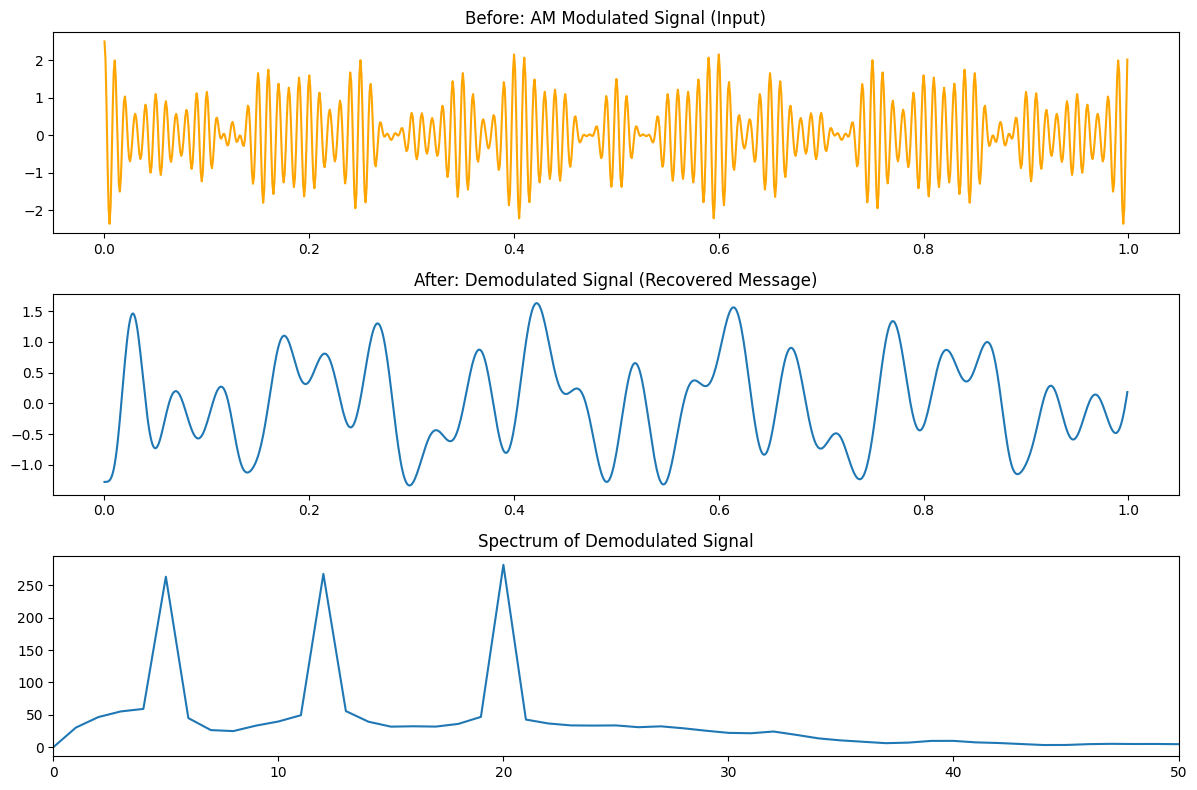

In [7]:
# 1. Rectification (Full-wave)
rectified_signal = np.abs(am_signal)

# 2. Low-pass Filter (to remove carrier and keep message)
def lowpass_filter(data, cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return lfilter(b, a, data)

# Cutoff slightly above our highest tone (20Hz)
demodulated_signal = lowpass_filter(rectified_signal, cutoff=30, fs=fs)

# Remove DC offset (the '1' from the AM formula)
demodulated_signal -= np.mean(demodulated_signal)
# Scale back up (approximate)
demodulated_signal *= 2 

# 3. Spectrum of demodulated signal
spectrum_demod = np.abs(np.fft.rfft(demodulated_signal))

# Plotting
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, am_signal, color='orange')
plt.title("Before: AM Modulated Signal (Input)")

plt.subplot(3, 1, 2)
plt.plot(t, demodulated_signal)
plt.title("After: Demodulated Signal (Recovered Message)")

plt.subplot(3, 1, 3)
plt.plot(freq, spectrum_demod)
plt.title("Spectrum of Demodulated Signal")
plt.xlim(0, 50) # Zoom into message frequencies

plt.tight_layout()
plt.show()